In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/diabetes.csv')

# 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
y=df['Outcome']
y.value_counts() # Outcome 값이 0과 1로 각각 몇 개씩 있는지 개수 확인
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
X=df.drop('Outcome',axis=1) # Outcome 열을 제외한 나머지 입력 변수(특성)들을 X에 저장
X.head()                    # X의 상위 5개 행을 출력

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
scaler = StandardScaler() # 각 특성(열)의 평균을 0, 표준편차를 1로 맞추기 위한 객체 생성
X = scaler.fit_transform(X) # 그 값을 이용해 데이터를 표준화(transform)

In [ ]:
# y의 범주형 값을 원-핫 인코딩(One-Hot Encoding)으로 변환한 뒤
# 넘파이 배열 형태로 저장
Y = pd.get_dummies(y).values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 8), (614, 2), (154, 8), (154, 2))

In [ ]:
# 다중분류(클래스 2개)용 Sequential 모델 생성
model = models.Sequential([
    # 입력층 + 첫 번째 은닉층
    # 뉴런 64개, 활성화 함수는 ReLU
    # input_shape=(X.shape[1],) 는 입력 특성 개수를 의미
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),

    # 드롭아웃 층
    # 학습 중 일부 뉴런(30%)을 무작위로 끄어 과적합을 방지
    layers.Dropout(0.3),

    # 두 번째 은닉층
    # 뉴런 32개, 활성화 함수는 ReLU
    layers.Dense(32, activation="relu"),

    # 출력층
    # 뉴런 2개 = 클래스가 2개라는 뜻
    # softmax를 사용해 각 클래스에 속할 확률을 출력
    layers.Dense(2, activation="softmax")   # 클래스 수 맞춤
])

# 모델 컴파일
model.compile(
    optimizer="adam",                  # 최적화 알고리즘
    loss="categorical_crossentropy",   # y가 원-핫 인코딩일 때 사용하는 손실 함수
    metrics=["accuracy"]               # 성능 평가 지표로 정확도 사용
)

# 모델 학습
history = model.fit(
    X_train, y_train,          # 학습 데이터
    validation_split=0.2,      # 학습 데이터의 20%를 검증 데이터로 사용
    epochs=50,                 # 전체 데이터를 50번 반복 학습
    batch_size=16,             # 한 번에 16개씩 묶어서 학습
    verbose=1                  # 학습 진행 과정 출력
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6191 - loss: 0.6628 - val_accuracy: 0.7398 - val_loss: 0.5777
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7047 - loss: 0.5658 - val_accuracy: 0.7724 - val_loss: 0.5198
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7251 - loss: 0.5549 - val_accuracy: 0.7805 - val_loss: 0.4925
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7495 - loss: 0.4932 - val_accuracy: 0.7886 - val_loss: 0.4775
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7617 - loss: 0.4892 - val_accuracy: 0.7805 - val_loss: 0.4750
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7699 - loss: 0.4856 - val_accuracy: 0.7967 - val_loss: 0.4753
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7637 - loss: 0.4789 - val_accuracy: 0.8049 - val_loss: 0.4800
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7556 - loss: 0.4772 - val_accuracy: 0.7967 - val_loss: 0.4782
Ep

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


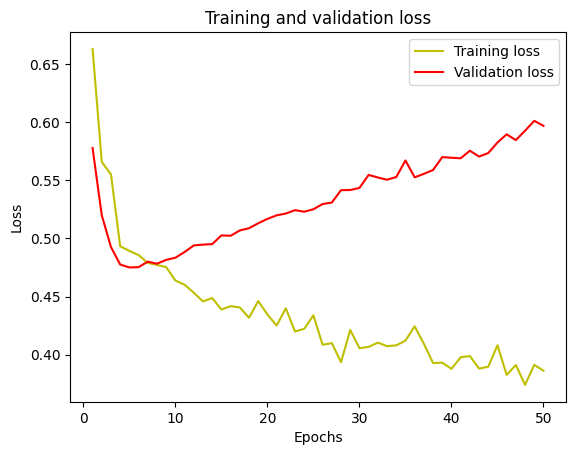

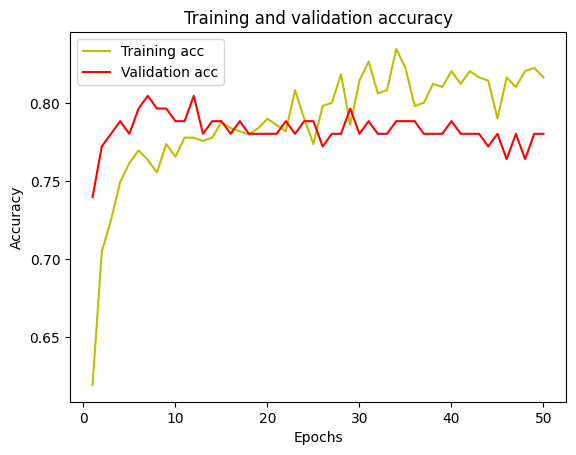

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       107
           1       0.64      0.62      0.63        47

    accuracy                           0.78       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.78      0.78      0.78       154

[[91 16]
 [18 29]]


In [ ]:

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))